In [1]:
import torch
import matplotlib.pyplot as plt
import deepwave
from deepwave import scalar
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# Device Configuration: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

cuda:0


<_io.BufferedReader name='./testmodel/marmousi_vp.bin'>
1500.0 5500.0


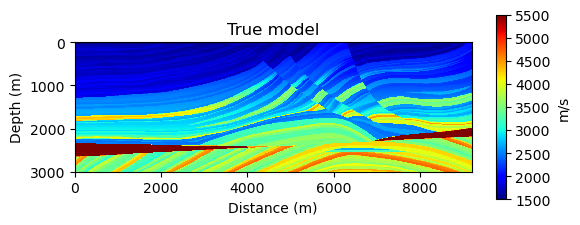

In [3]:
dirmodel = './testmodel/'

modelbin='marmousi_vp.bin' # binary file containing velocity model
nz = 751
dz = 4.0
oz = 0.0
ny = 2301
dy = 4.0
oy = 0.0

#reading velocity model from file
f =  open(dirmodel+modelbin,'rb')
print(f)
vel = np.fromfile(f,dtype='f4',count=nz*ny)
vel = vel.reshape([nz, ny],order='F')
f.close()

# Construct z and y axes arrays
z_values = np.arange(oz, oz + nz * dz, dz)
y_values = np.arange(oy, oy + ny * dy, dy)

# Obtain max and min values
max_value = np.max(vel)
min_value = np.min(vel)
print(min_value,max_value)

# Plot the image
plt.imshow(vel, cmap='jet', extent=[y_values[0], y_values[-1], z_values[-1], z_values[0]],interpolation='none' )
# Adjust color scale limits
plt.clim(vmin=min_value, vmax=max_value)
#Add colorbar
cbar = plt.colorbar(shrink=0.5)
cbar.ax.tick_params(labelsize=10)
tick_values = np.arange(min_value, max_value+0.1,500)
cbar.set_ticks(tick_values)

# Add title and labels
plt.title('True model')
plt.xlabel('Distance (m)')
plt.ylabel('Depth (m)')
cbar.set_label('m/s')

plt.show()



In [4]:
# Set acquisition parameters for seismic modeling with Deepwave

dx = 4.0 # grid spacing
dt = 0.004 
nt = 750
peak_freq = 25
peak_time = 1.5 / peak_freq
num_dims = 2 #2D modeling

num_shots = 3
num_sources_per_shot = 1
num_receivers_per_shot = 384
source_spacing = 1000 
receiver_spacing = 6 
first_source = 150  
source_depth = 2  
first_receiver = 0
receiver_depth = 2


# source_locations
source_locations = torch.zeros(num_shots,num_sources_per_shot,2,
                               dtype=torch.long, device=device)
source_locations[..., 1] = source_depth
source_locations[:, 0, 0] = torch.arange(num_shots)*source_spacing+first_source

# receiver_locations
receiver_locations = torch.zeros(num_shots,num_receivers_per_shot, 2,
                                 dtype=torch.long, device=device)
receiver_locations[..., 1] = receiver_depth
receiver_locations[:, :, 0] = ((torch.arange(num_receivers_per_shot)*receiver_spacing + first_receiver)
    .repeat(num_shots, 1))

# source_amplitudes (Ricker)
source_amplitudes = (deepwave.wavelets.ricker(peak_freq, nt, dt,peak_time)
    .repeat(num_shots,num_sources_per_shot, 1)
    .to(device))
# source_amplitudes.cpu().numpy().tofile(dirmodel+'pulse-ricker.bin')

/tmp/ipykernel_7367/832178282.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4421.)
  plt.plot(source_amplitudes.cpu().T[:, 0, 0])


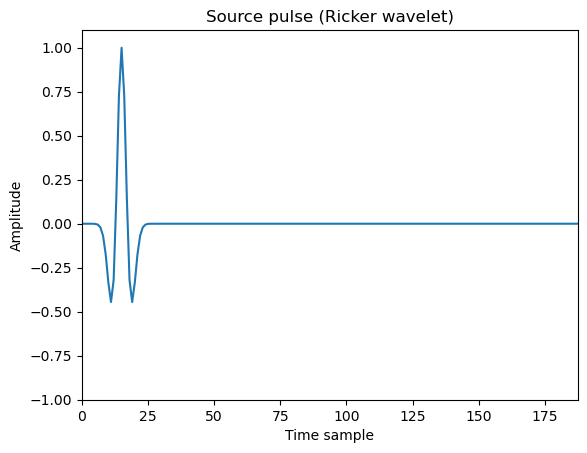

In [5]:
plt.plot(source_amplitudes.cpu().T[:, 0, 0])
plt.ylim(-1, 1+0.1)
plt.xlim(0, nt/4) 
plt.title('Source pulse (Ricker wavelet)')
plt.ylabel('Amplitude')
plt.xlabel('Time sample')
plt.show()

In [6]:
print(vel.shape)
model_true = torch.tensor(vel, dtype=torch.float32, device=device).T
max_true=max_value
print(model_true.shape)
print(source_locations)

(751, 2301)
torch.Size([2301, 751])
tensor([[[ 150,    2]],

        [[1150,    2]],

        [[2150,    2]]], device='cuda:0')


In [7]:
# Wavefield modeling 
out = scalar(model_true, dx, dt, max_vel=float(max_true),
              source_amplitudes=source_amplitudes,
              source_locations=source_locations,
              receiver_locations=receiver_locations,
              accuracy=8,
              pml_freq=peak_freq,pml_width=[30,30,30,30])
data=out[-1] 


In [8]:
# save modeled data to file
# receiver_amplitudes.cpu().numpy().tofile('data-marmousi.bin')

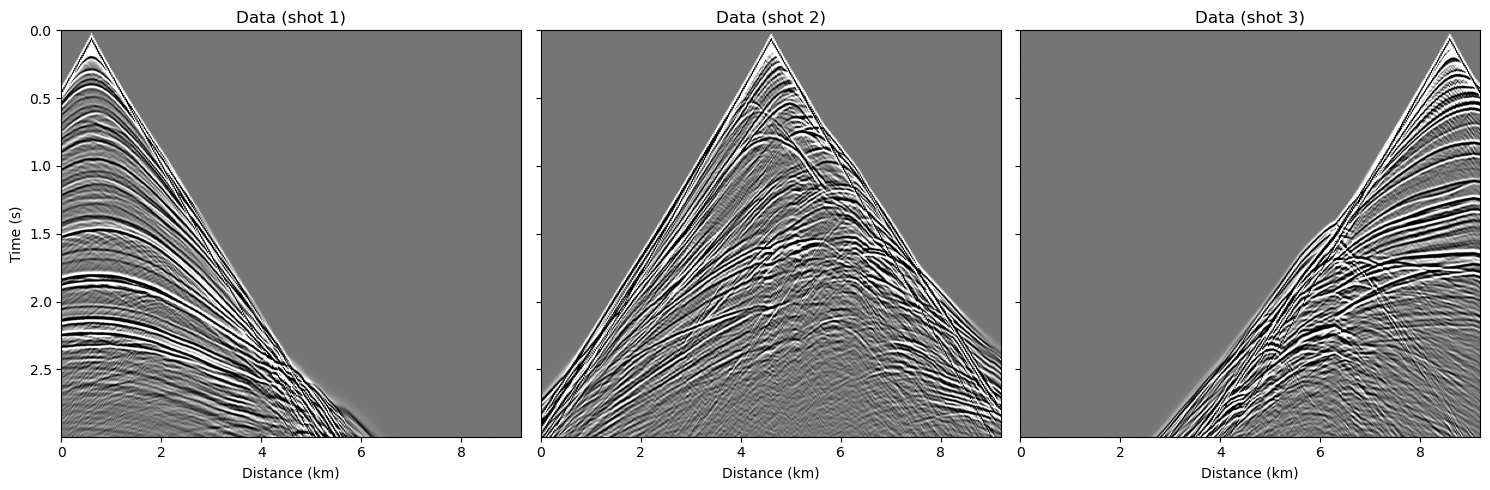

In [19]:
# Time vector
time = np.arange(nt) * dt
# Constants to convert units
km2m = 1000  # Conversion factor: km/s to m/s
m2km = 1 / km2m  # Conversion factor: m/s to km/s
# Distance vector
distance = np.arange(num_receivers_per_shot) * receiver_spacing * dx + first_receiver * dx
distance *= m2km 
# Determine vmin and vmax for consistent scaling across plots
vmin, vmax = torch.quantile(data, torch.tensor([0.05, 0.95]).to(device))
# Create the subplots
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Plot data for a specific shot 
ishot = 0  # Index of the shot to plot
ax[0].imshow(
    data[ishot, :].cpu().T,
    aspect='auto',
    cmap='gray',
    vmin=vmin,
    vmax=vmax,
    extent=[distance[0], distance[-1], time[-1], time[0]]
)
ax[0].set_title("Data (shot {})".format(ishot+1))
ax[0].set_xlabel("Distance (km)")
ax[0].set_ylabel("Time (s)")

# Plot data for a specific shot 
ishot = 1  # Index of the shot to plot
ax[1].imshow(
    data[ishot, :].cpu().T,
    aspect='auto',
    cmap='gray',
    vmin=vmin,
    vmax=vmax,
    extent=[distance[0], distance[-1], time[-1], time[0]]
)
ax[1].set_title("Data (shot {})".format(ishot+1))
ax[1].set_xlabel("Distance (km)")
# ax[1].set_ylabel("Time (s)")

# Plot data for a specific shot 
ishot = 2  # Index of the shot to plot
ax[2].imshow(
    data[ishot, :].cpu().T,
    aspect='auto',
    cmap='gray',
    vmin=vmin,
    vmax=vmax,
    extent=[distance[0], distance[-1], time[-1], time[0]]
)
ax[2].set_title("Data (shot {})".format(ishot+1))
ax[2].set_xlabel("Distance (km)")
# ax[3].set_ylabel("Time (s)")
# Adjust layout and show the plots
plt.tight_layout()
plt.show()

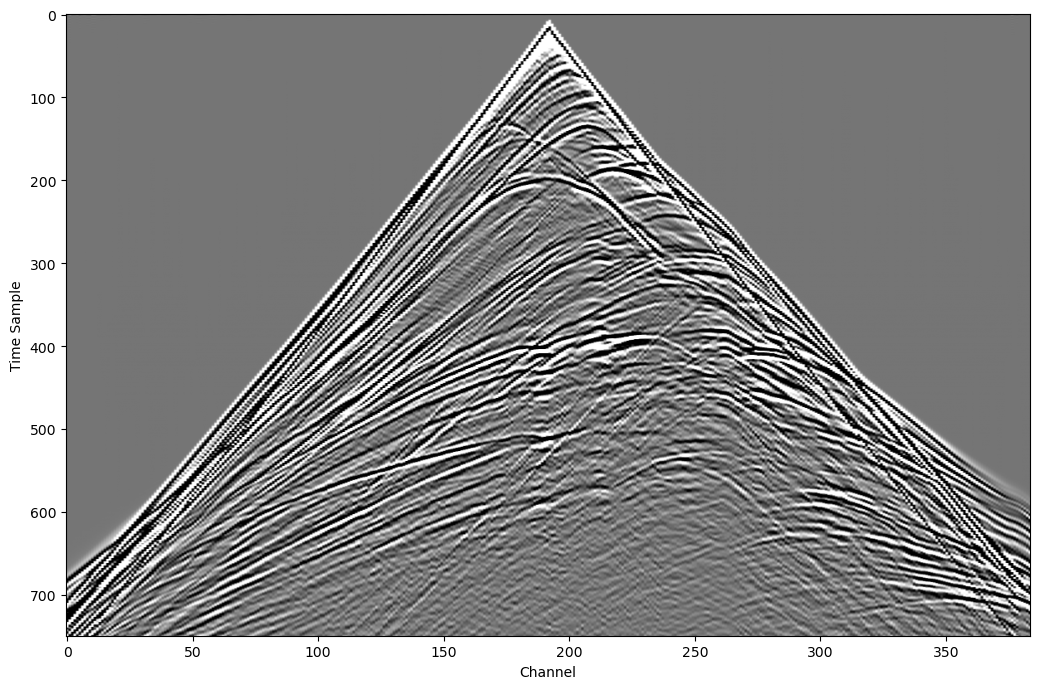

In [20]:
# Plot: visualize shot gather (single plot)
receiver_amplitudes = out[-1]
plt.figure(figsize=(10.5, 7))
plt.imshow(receiver_amplitudes[1].cpu().T, aspect='auto', cmap='gray', vmin=vmin, vmax=vmax)
plt.xlabel("Channel")
plt.ylabel("Time Sample")
plt.tight_layout()
plt.savefig('example_forward_modeling.jpg')